#### Завдання 1. Виявлення емоцій на обличчях (FER-2013)
- Мета: Навчитися класифікувати емоції на реальних обличчях.
- Датасет: FER-2013 (https://www.kaggle.com/datasets/msambare/fer2013)
- Опис:
    - Побудувати CNN з 2–3 conv шарами + 2 fc шари.
    - Навчити на тренувальних даних.
    - Оцінити точність на тесті.
    - Візуалізувати правильні та неправильні передбачення.
- Очікуваний результат: Модель визначає емоції (радість, сум, злість і т.д.) з точністю ~65–70%+.

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Знайдені емоції: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.3001 - loss: 1.7378 - val_accuracy: 0.4061 - val_loss: 1.5486
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.4141 - loss: 1.5086 - val_accuracy: 0.4682 - val_loss: 1.3914
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.4627 - loss: 1.3975 - val_accuracy: 0.4967 - val_loss: 1.3313
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.4913 - loss: 1.3293 - val_accuracy: 0.5176 - val_loss: 1.2571
Epoch 5/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.5166 - loss: 1.2674 - val_accuracy: 0.5319 - val_loss: 1.2354
Epoch 6/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.5339 - loss: 1.2226 - val_accuracy: 0.5430 - val_loss: 1.2045
Epoch 7/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.5544 - loss: 1.1793 - val_accuracy: 0.5429 - val_loss: 1.2085
Epoch 8/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.5701 - loss: 1.1364 - 

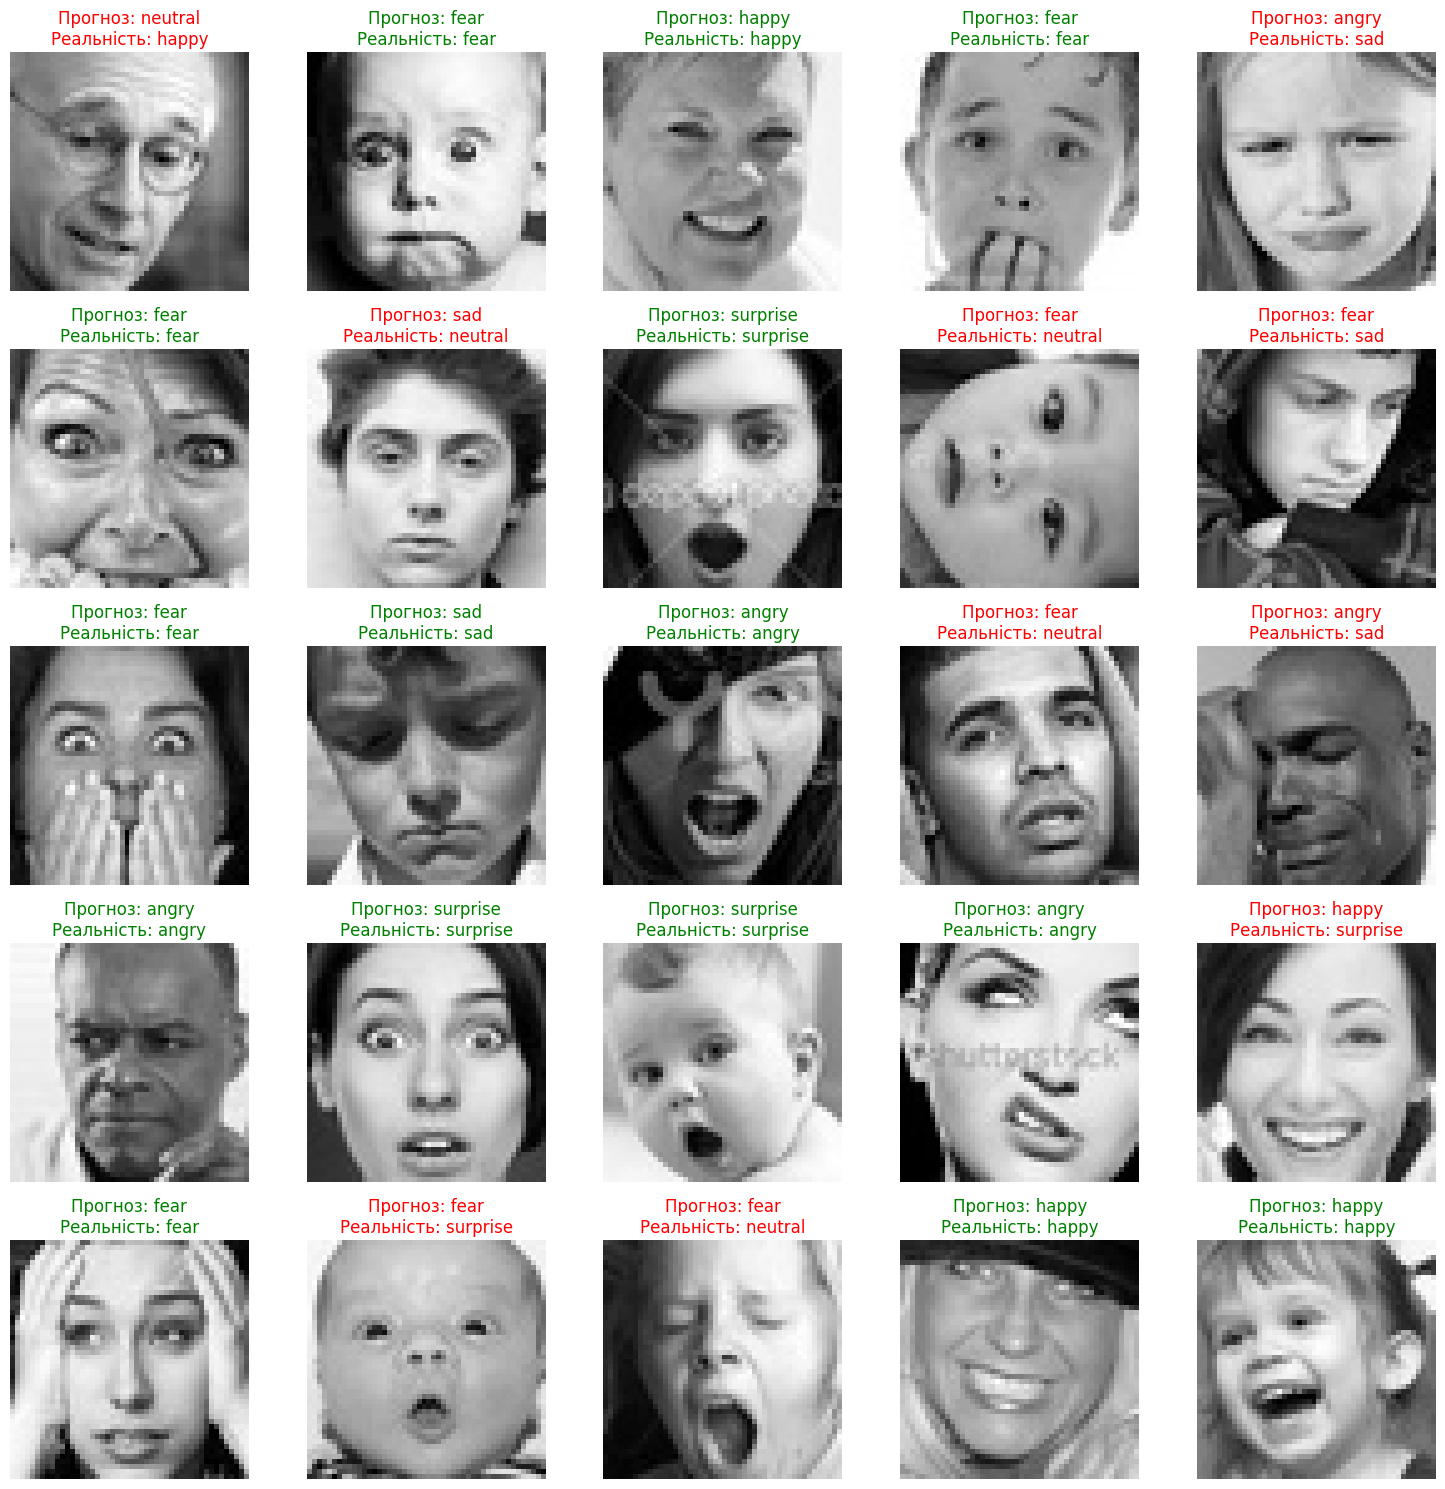

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from keras import Sequential, Input
from keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPooling2D
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# -Підготуємо дані
train_dir = 'FER-2013/train'
test_dir = 'FER-2013/test'

# Перевірка, чи існують вказані шляхи
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    print("ПОМИЛКА: Шляхи до даних не знайдено.")
    print(f"Перевірте, чи правильно вказано шлях '{train_dir}' та '{test_dir}'")
else:

    # Створимо генератори даних. Вони будуть зчитувати зображення з папок
    # Розмір зображення (в датасеті FER2013 48x48)
    IMG_HEIGHT = 48
    IMG_WIDTH = 48    
    BATCH_SIZE = 64  # Розмір "пачки" (batches) зображень, які одночасно обробляються

    # Генератор для тренувальних даних
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode='grayscale', # Емоції добре розпізнаються і без кольору
        class_mode='categorical' # Тип класифікації - на кілька категорій (емоцій)
    )

    # Генератор для тестових даних
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='categorical'
    )

    # Отримаємо назви класів (емоцій)
    class_labels = list(train_generator.class_indices.keys())
    print("Знайдені емоції:", class_labels)


    
    # Побудуємо МОДЕЛІ CNN 
    # Створимо послідовну модель (шар за шаром)
    model = Sequential([
        Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),  

        # 1-й згортковий блок
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # 2-й згортковий блок
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        # 3-й згортковий блок (додатковий, для кращої точності)
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
                
        Flatten(),  # "Випрямемо" дані з 2D в 1D вектор для повнозв'язних шарів
        # 1-й повнозв'язний шар (Full Connected)
        Dense(128, activation='relu'),
        Dropout(0.5),  # Включимо Dropout - техніку для боротьби з "перенавчанням" моделі
        # 2-й (вихідний) повнозв'язний шар
        Dense(len(class_labels), activation='softmax')  # Використаємо 'softmax', щоб перетворити виходи в ймовірності для кожного класу.
    ])
   
    model.summary()   # Виведемо сумарну структуру нашої моделі
    

    # Налаштуємо процес навчання
    model.compile(
        optimizer='adam', 
        loss='categorical_crossentropy', 
        metrics=['accuracy'] 
    )

    # Тренуємо модель
    history = model.fit(
        train_generator,
        epochs=40, # Це скільки разів модель "подивиться" на всі тренувальні дані
        validation_data=test_generator  # Це дані для перевірки якості після кожної епохи
    )

    print("\nОцінка моделі на тестових даних:")
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Точність на тестових даних: {test_acc*100:.2f}%")

    print("\nВізуалізація результатів (правильних та неправильних передбачень)...")
    
    x_test, y_test = next(test_generator)  # Отримуємо одну "пачку" зображень і міток з тестового генератора    
    predictions = model.predict(x_test)    # Робимо передбачення для цієї пачки    
    predicted_labels = np.argmax(predictions, axis=1)  # Отримуємо індекс передбаченого класу (емоції)    
    true_labels = np.argmax(y_test, axis=1)  # Отримуємо індекс справжнього класу
    
    plt.figure(figsize=(15, 15))  # Створимо полотно для візуалізації
    
    for i in range(min(25, len(x_test))):  # Проходимо по перших 25 зображеннях з пачки
        plt.subplot(5, 5, i + 1)        
        plt.imshow(np.squeeze(x_test[i]), cmap='gray')  # Відображаємо зображення
        
        # Отримаємо назву передбаченої та справжньої емоції
        predicted_emotion = class_labels[predicted_labels[i]]
        true_emotion = class_labels[true_labels[i]]
        
        # Визначимо колір для заголовка
        if predicted_emotion == true_emotion:
            color = "green" # Зелений, якщо вгадали
        else:
            color = "red"   # Червоний, якщо помилились
            
        plt.title(f"Прогноз: {predicted_emotion}\nРеальність: {true_emotion}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

#### Завдання 5. Виявлення жестів рук (Sign Language MNIST або ASL)
- Мета: Навчитися класифікувати жести рук.
- Датасет: Sign Language MNIST (https://www.kaggle.com/datasets/datamunge/sign-language-mnist/data)
- Опис:
    - Побудувати CNN для класифікації жестів (A–Z).
    - Навчити на тренувальних даних.
    - Оцінити точність на тесті.
    - Візуалізувати кілька неправильних передбачень.
- Очікуваний результат: Модель розпізнає жести рук із точністю ~85–90%.

Дані успішно завантажено.
Розмір тренувальних даних: (27455, 28, 28, 1)
Розмір тестових даних: (7172, 28, 28, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation_1 (RandomRotation)   │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_1 (RandomZoom)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation_1                 │ (None, 28, 28, 1)           │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 14, 14, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 7, 7, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 7, 7, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 3, 3, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 3, 3, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 24)                  │           6,168 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 967,704 (3.69 MB)

 Trainable params: 966,808 (3.69 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 46s 197ms/step - accuracy: 0.3758 - loss: 2.0252 - val_accuracy: 0.1323 - val_loss: 5.6346
Epoch 2/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 195ms/step - accuracy: 0.7375 - loss: 0.7687 - val_accuracy: 0.3844 - val_loss: 2.1453
Epoch 3/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 189ms/step - accuracy: 0.8655 - loss: 0.3937 - val_accuracy: 0.9283 - val_loss: 0.1831
Epoch 4/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 191ms/step - accuracy: 0.9113 - loss: 0.2605 - val_accuracy: 0.8823 - val_loss: 0.3094
Epoch 5/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.9388 - loss: 0.1856 - val_accuracy: 0.8781 - val_loss: 0.4042
Epoch 6/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 45s 207ms/step - accuracy: 0.9482 - loss: 0.1593 - val_accuracy: 0.9884 - val_loss: 0.0372
Epoch 7/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.9562 - loss: 0.1295 - val_accuracy: 0.8526 - val_loss: 0.4543
Epoch 8/40
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 196ms/step - accuracy: 0.9660 - loss: 0

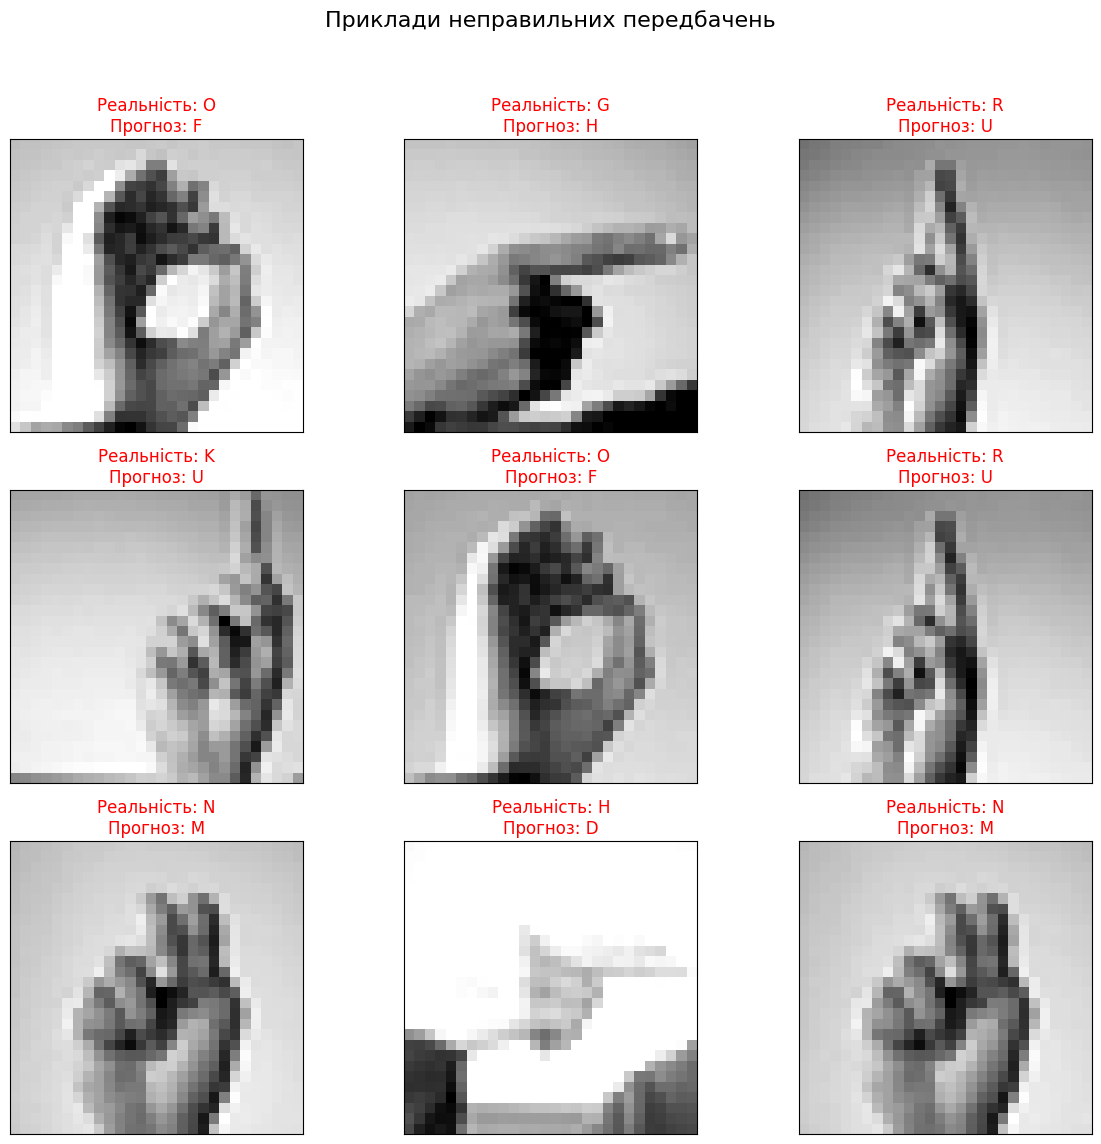

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Імпортуємо компоненти з tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, RandomRotation, RandomZoom, RandomTranslation
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report

# --- Завантажимо та підготуємо дані ---
folder_path = 'Sign Language MNIST/'

try:
    train_df = pd.read_csv(os.path.join(folder_path, 'sign_mnist_train.csv'))
    test_df = pd.read_csv(os.path.join(folder_path, 'sign_mnist_test.csv'))
    print("Дані успішно завантажено.")
except FileNotFoundError:
    print(f"ПОМИЛКА: Переконайтеся, що файли знаходяться у папці '{folder_path}'")
    exit()

# Відокремлюємо мітки (Y) від пікселів (X)
y_train = train_df['label']
y_test = test_df['label']
del train_df['label']
del test_df['label']
x_train = train_df.values
x_test = test_df.values

# Перетворимо мітки у формат one-hot encoding
label_binarizer = LabelBinarizer()
y_train = label_binarizer.fit_transform(y_train)
y_test = label_binarizer.transform(y_test)

# Нормалізуємо значення пікселів (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Змінимо форму даних на зображення 28x28x1
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Розмір тренувальних даних: {x_train.shape}")
print(f"Розмір тестових даних: {x_test.shape}")


# Побудуємо модель CNN з аугментацією та BatchNormalization
model = Sequential([
    Input(shape=(28, 28, 1)),    

    # --- Аугментація зображень ---
    RandomRotation(0.1),       # обертання ±10%
    RandomZoom(0.1),           # зум ±10%
    RandomTranslation(0.1, 0.1),  # зсув ±10% по ширині та висоті

    # --- 1-й згортковий блок ---
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),      # додаємо нормалізацію для стабільності
    MaxPooling2D((2, 2)),

    # --- 2-й згортковий блок ---
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # --- 3-й згортковий блок для більшої потужності ---
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Dropout(0.3),
    Flatten(),

    # --- Повнозв'язні шари ---
    Dense(256, activation='relu'),
    Dropout(0.5),

    # --- Вихідний шар: 24 класи (A–Z без J) ---
    Dense(24, activation='softmax')
])

# Компіліруємо модель
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# Використаємо EarlyStopping для автоматичної зупинки при стабілізації точності ---
early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=5,          # чекаємо 5 епох після останнього покращення
    restore_best_weights=True
)

# Почнемо навчання моделі
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=40,                 # збільшена кількість епох для досягнення 85–90% точності
    validation_data=(x_test, y_test),
    callbacks=[early_stop]     # додаємо EarlyStopping
)


# Оцінемо моделі на тестових даних
print("\nОцінка моделі на тестових даних:")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Точність на тестових даних: {test_acc*100:.2f}%")


# --- Передбачення та класифікаційний звіт ---
predictions = model.predict(x_test)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Відповідні назви класів (A–Z без J)
class_names = [chr(ord('A') + i) for i in range(25) if i != 9] 

print("\nЗвіт по класифікації:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


# Візуалізуємо неправильні передбачення
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]
print(f"\nЗнайдено {len(incorrect_indices)} неправильних передбачень.")

plt.figure(figsize=(12, 12))
plt.suptitle("Приклади неправильних передбачень", fontsize=16)
for i, idx in enumerate(incorrect_indices[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray', interpolation='none')
    true_label = class_names[y_true_classes[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    plt.title(f"Реальність: {true_label}\nПрогноз: {pred_label}", color='red')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
